### **Autor:** David Roca Tauste

---
---
# **📌ACTIVIDAD 1: COMPRENDER EL AUDIO**
---
---

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

fichero_audio = "../JoseRosa/0-JOSROSROD-0.wav"
frecuencia, audio = wavfile.read(fichero_audio)
duracion = round(audio.shape[0] / float(frecuencia), 3)
print ('\nMuestras:', audio.shape)
print ('Tipo de dato de cada muestra:', audio.dtype)
print ('Duración:', duracion, 'segundos')


Muestras: (63920, 2)
Tipo de dato de cada muestra: int16
Duración: 1.449 segundos


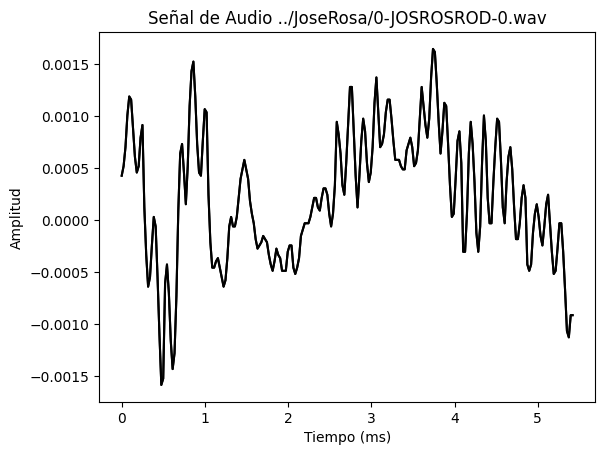

In [10]:
audio = audio / 2.0**15  # Normalizar
audio1 = audio[:240]  # Dibujar 240 muestras
x_val = np.arange(0, len(audio1), 1) / float(frecuencia)
x_val *= 1000

plt.plot(x_val, audio1, color="black")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Amplitud")
plt.title("Señal de Audio " + fichero_audio)
plt.show()


Muestras: (79872, 2)
Tipo de dato de cada muestra: int16
Duración: 1.664 segundos


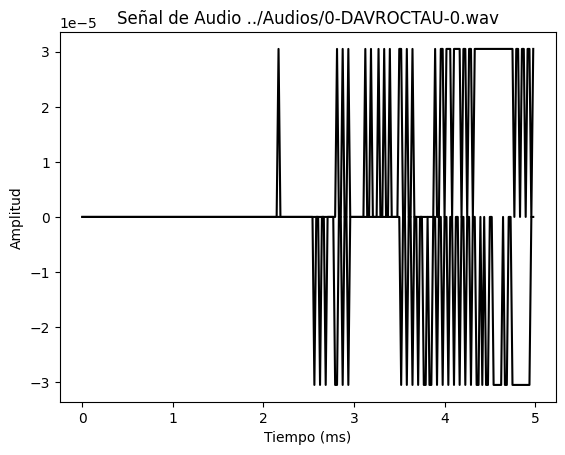

In [11]:
fichero_audio = "../Audios/0-DAVROCTAU-0.wav"
frecuencia, audio = wavfile.read(fichero_audio)
duracion = round(audio.shape[0] / float(frecuencia), 3)
print ('\nMuestras:', audio.shape)
print ('Tipo de dato de cada muestra:', audio.dtype)
print ('Duración:', duracion, 'segundos')

audio = audio / 2.0**15  # Normalizar
audio1 = audio[:240]  # Dibujar 240 muestras
x_val = np.arange(0, len(audio1), 1) / float(frecuencia)
x_val *= 1000

plt.plot(x_val, audio1, color="black")
plt.xlabel("Tiempo (ms)")
plt.ylabel("Amplitud")
plt.title("Señal de Audio " + fichero_audio)
plt.show()

## ENTREGA 2: Copia el código y lo modificas para que coja tu fichero cuando pronuncias el cero.
### a) ¿La onda de tu gráfico es exactamente igual que la de mi pronunciación o tiene diferencias?
La onda de mi gráfico tiene bastantes diferencias.

### b) Entrega el gráfico de tu onda de audio junto a la mía.
Se encuentran ambos arriba.

In [12]:
audio_transformado = np.fft.fft(audio)  # FFT
mitad = int(np.ceil((len(audio) + 1) / 2.0))
audio_transformado = abs(audio_transformado[0:mitad])
audio_transformado **= 2

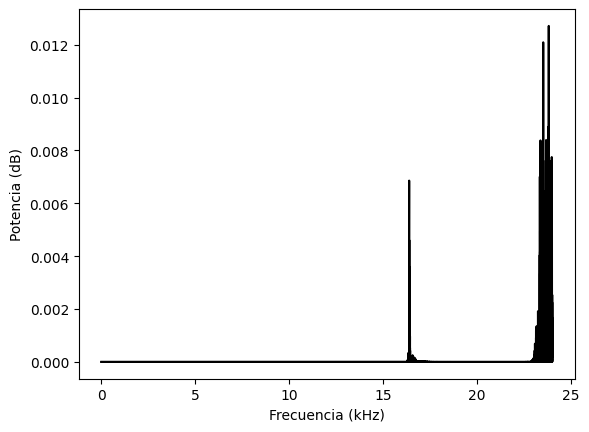

In [13]:
potencia = 20 * np.log10(audio_transformado + 1)
x_val = np.arange(0, mitad, 1) * (frecuencia / len(audio)) / 1000.0

plt.figure()
plt.plot(x_val, potencia, color="black")
plt.xlabel("Frecuencia (kHz)")
plt.ylabel("Potencia (dB)")
plt.show()

---
## GENERAR NUESTRO PROPIO AUDIO

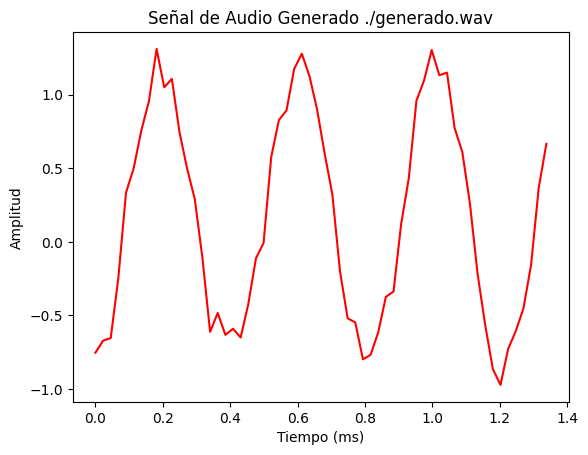

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile

duracion = 3
frecuencia_tono = 587
min_val = -2 * np.pi
max_val = 2 * np.pi
frecuencia = 44100

t = np.linspace(min_val, max_val, int(duracion * frecuencia), endpoint=False)
audio = np.sin(2 * np.pi * frecuencia_tono * t)
ruido = 0.4 * np.random.rand(int(duracion * frecuencia))
audio += ruido

escala = pow(2, 15) - 1
audio_normalizado = audio / np.max(np.abs(audio))
audio_escalado = np.int16(audio_normalizado * escala)
x_val = np.arange(0, len(audio), 1) / float(frecuencia)
x_val *= 1000

plt.plot(x_val[:60], audio[:60], color='red')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud')

# Guardar el audio a un fichero
fichero_salida = './generado.wav'
wavfile.write(fichero_salida, frecuencia, audio_escalado)
plt.title('Señal de Audio Generado ' + fichero_salida)
plt.show()

---
## EXTRACCIÓN DE CARACTERÍSTICAS DESDE UN FICHERO DE AUDIO


Muestras: (66150,)
Tipo de dato de cada muestra: float32
Duración: 3 segundos
Número de frames = 130
Longitud de cada característica = 20


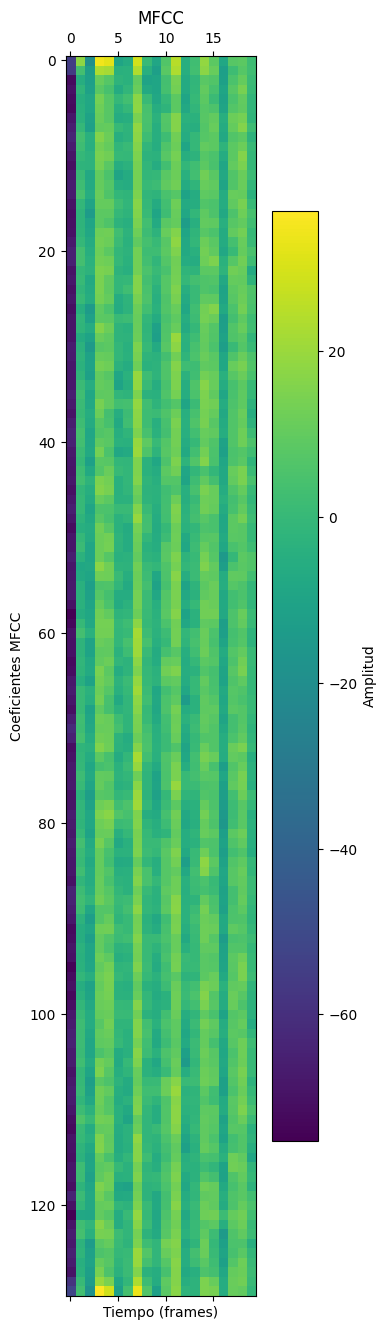

In [15]:
# Extraer las características de un audio
from librosa.feature import mfcc
import librosa
import matplotlib.pyplot as plt

fichero_audio = "./generado.wav"

audio, frecuencia = librosa.load(fichero_audio)
caracteristicas_mfcc = mfcc(sr=frecuencia, y=audio)

print ('\nMuestras:', audio.shape)
print ('Tipo de dato de cada muestra:', audio.dtype)
print ('Duración:', duracion, 'segundos')
print("Número de frames =", caracteristicas_mfcc.shape[1])
print("Longitud de cada característica =", caracteristicas_mfcc.shape[0])

# Dibujarlas
caracteristicas_mfcc = caracteristicas_mfcc.T
plt.matshow(caracteristicas_mfcc)
plt.title("MFCC")
plt.xlabel("Tiempo (frames)")
plt.ylabel("Coeficientes MFCC")
plt.colorbar(label="Amplitud")
plt.show()

## ENTREGA 3: Haz lo mismo con tu fichero de audio del número cero y entregas captura del resultado de la ejecución.
Se encuentra abajo.


Muestras: (36692,)
Tipo de dato de cada muestra: float32
Duración: 1.664 segundos
Número de frames = 20
Longitud de cada característica = 72


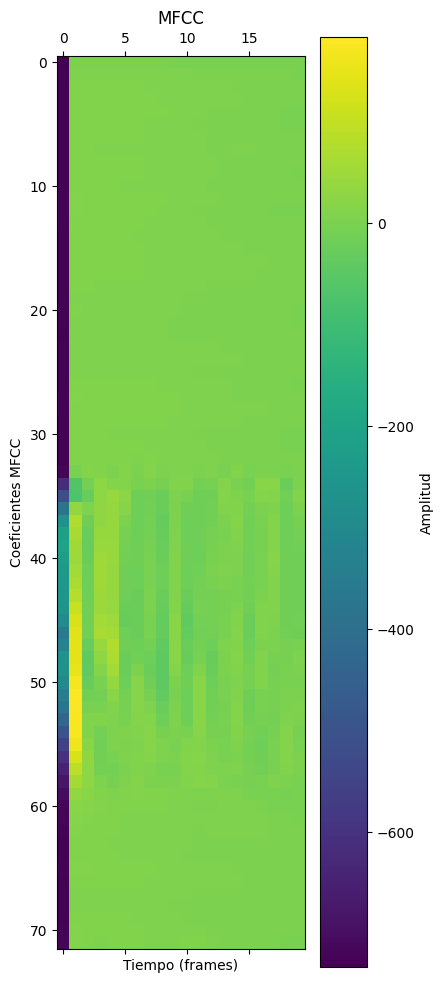

In [16]:
fichero_audio = "../Audios/0-DAVROCTAU-0.wav"

audio, frecuencia = librosa.load(fichero_audio)
duracion = round(audio.shape[0] / float(frecuencia), 3)
caracteristicas_mfcc = mfcc(sr=frecuencia, y=audio)

print ('\nMuestras:', audio.shape)
print ('Tipo de dato de cada muestra:', audio.dtype)
print ('Duración:', duracion, 'segundos')
print("Número de frames =", caracteristicas_mfcc.shape[0])
print("Longitud de cada característica =", caracteristicas_mfcc.shape[1])

# Dibujarlas
caracteristicas_mfcc = caracteristicas_mfcc.T
plt.matshow(caracteristicas_mfcc)
plt.title("MFCC")
plt.xlabel("Tiempo (frames)")
plt.ylabel("Coeficientes MFCC")
plt.colorbar(label="Amplitud")
plt.show()